In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from IPython.display import Markdown, display

from google.colab import drive

In [ ]:
drive.mount('/content/drive')
T100path = "/content/drive/My Drive/DAT 490 Datasets/T100-Merged.csv"
F41path  = "/content/drive/My Drive/DAT 490 Datasets/F41_1.2-Merged.csv"
OTPpath  = "/content/drive/My Drive/DAT 490 Datasets/OTP_Kaggle.csv"

T100    = pd.read_csv(T100path, low_memory=False)
F41     = pd.read_csv(F41path)
otp_raw = pd.read_csv(OTPpath)

print("T100 shape:", T100.shape)
print("F41 shape: ", F41.shape)
print("OTP shape: ", otp_raw.shape)
print("\nOTP columns:", otp_raw.columns.tolist())
print("OTP years:  ", sorted(otp_raw['year'].unique()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
T100 shape: (2193983, 38)
F41 shape:  (3678, 53)
OTP shape:  (398233, 21)

OTP columns: ['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
OTP years:   [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [ ]:
t100 = T100.copy()
f41  = F41.copy()

t100_numeric_cols = [
    'Quarterly Net Income','PASSENGERS','FREIGHT','MAIL','DISTANCE',
    'AIRLINE_ID','ORIGIN_AIRPORT_ID','ORIGIN_CITY_MARKET_ID',
    'DEST_AIRPORT_ID','DEST_CITY_MARKET_ID','YEAR','QUARTER',
    'MONTH','DISTANCE_GROUP'
]
for col in t100_numeric_cols:
    if col in t100.columns:
        t100[col] = pd.to_numeric(t100[col], errors='coerce')

f41_numeric_cols = [
    'NET_INCOME','OP_PROFIT_LOSS','TRANS_REV_PAX','MAIL',
    'TOTAL_PROPERTY','PROP_FREIGHT','PROP_BAG','TOTAL_CHARTER',
    'CHARTER_PAX','CHARTER_PROP','TOTAL_MISC_REV','RES_CANCEL_FEES',
    'MISC_OP_REV','PUB_SVC_REVENUE','TRANS_REVENUE','OP_REVENUES',
    'FLYING_OPS','MAINTENANCE','PAX_SERVICE','AIRCFT_SERVICES',
    'PROMOTION_SALES','GENERAL_ADMIN','GENERAL_SERVICES','DEPREC_AMORT',
    'TRANS_EXPENSES','OP_EXPENSES','INTEREST_LONG_DEBT','INTEREST_EXP_OTH',
    'FOREIGN_EX_GAINS','CAP_GAINS_PROP','CAP_GAINS_OTHER','OTHER_INCOME_NET',
    'NON_OP_INCOME','INCOME_PRE_TAX','INCOME_TAX','INCOME_BEFORE_OTH',
    'DISCONT_OPS','EXTRA_ITEMS','INCOME_TAX_EXTRA','INCOME_TAX_CREDITS',
    'ACCTG_CHANGES','AIRLINE_ID','YEAR','QUARTER'
]
for col in f41_numeric_cols:
    if col in f41.columns:
        f41[col] = pd.to_numeric(f41[col], errors='coerce')

print("T100 missing net income:", t100['Quarterly Net Income'].isna().sum())
print("F41 missing NET_INCOME: ", f41['NET_INCOME'].isna().sum())

T100 missing net income: 369002
F41 missing NET_INCOME:  0


In [ ]:
t100_agg = (
    t100.groupby('Match Key Carrier-Quarter-Year')
    .agg({
        'Quarterly Net Income':     'first',
        'PASSENGERS':               'sum',
        'FREIGHT':                  'sum',
        'MAIL':                     'sum',
        'DISTANCE':                 'sum',
        'AIRLINE_ID':               'first',
        'UNIQUE_CARRIER':           'first',
        'UNIQUE_CARRIER_NAME':      'first',
        'UNIQUE_CARRIER_ENTITY':    'first',
        'REGION':                   'first',
        'CARRIER':                  'first',
        'CARRIER_NAME':             'first',
        'CARRIER_GROUP':            'first',
        'CARRIER_GROUP_NEW':        'first',
        'YEAR':                     'first',
        'QUARTER':                  'first',
        'MONTH':                    'nunique',
        'DISTANCE_GROUP':           'mean',
        'ORIGIN_AIRPORT_ID':        'nunique',
        'DEST_AIRPORT_ID':          'nunique',
        'ORIGIN_CITY_MARKET_ID':    'nunique',
        'DEST_CITY_MARKET_ID':      'nunique'
    })
    .reset_index()
)

print("t100_agg shape:", t100_agg.shape)
t100_agg.head()

t100_agg shape: (4440, 23)


,Match Key Carrier-Quarter-Year,Quarterly Net Income,PASSENGERS,FREIGHT,MAIL,DISTANCE,AIRLINE_ID,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,...,CARRIER_GROUP,CARRIER_GROUP_NEW,YEAR,QUARTER,MONTH,DISTANCE_GROUP,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,DEST_CITY_MARKET_ID
0,02Q20224,NaN,51,0,0,2606,21040.0,02Q,Titan Airways,71004,...,0,0.0,2022,4,1,3.0,2,2,2,2
1,02Q20231,NaN,54,0,0,1425,21040.0,02Q,Titan Airways,71004,...,0,0.0,2023,1,1,3.0,1,1,1,1
2,02Q20234,NaN,7,0,0,1402,21040.0,02Q,Titan Airways,71004,...,0,0.0,2023,4,1,3.0,1,1,1,1
3,02Q20241,NaN,44,0,0,3928,21040.0,02Q,Titan Airways,71004,...,0,0.0,2024,1,1,8.0,1,1,1,1
4,02Q20242,NaN,43,0,0,1446,21040.0,02Q,Titan Airways,71004,...,0,0.0,2024,2,2,2.0,2,2,2,2


In [ ]:
t100['route_key'] = (
    t100['ORIGIN_AIRPORT_ID'].astype(str) + "_" +
    t100['DEST_AIRPORT_ID'].astype(str)
)
route_counts = (
    t100.groupby('Match Key Carrier-Quarter-Year')['route_key']
    .nunique()
    .reset_index(name='route_count')
)
t100_agg = t100_agg.merge(
    route_counts,
    on='Match Key Carrier-Quarter-Year',
    how='left'
)
print("t100_agg shape after route merge:", t100_agg.shape)

t100_agg shape after route merge: (4440, 24)


In [ ]:
if 'MAIL' in f41.columns:
    f41 = f41.rename(columns={'MAIL': 'F41_MAIL'})

f41_agg = (
    f41.groupby('Match Key Carrier-Quarter-Year')
    .agg({
        'NET_INCOME':           'first',
        'OP_PROFIT_LOSS':       'first',
        'TRANS_REV_PAX':        'first',
        'F41_MAIL':             'first',
        'TOTAL_PROPERTY':       'first',
        'PROP_FREIGHT':         'first',
        'PROP_BAG':             'first',
        'TOTAL_CHARTER':        'first',
        'CHARTER_PAX':          'first',
        'CHARTER_PROP':         'first',
        'TOTAL_MISC_REV':       'first',
        'RES_CANCEL_FEES':      'first',
        'MISC_OP_REV':          'first',
        'PUB_SVC_REVENUE':      'first',
        'TRANS_REVENUE':        'first',
        'OP_REVENUES':          'first',
        'FLYING_OPS':           'first',
        'MAINTENANCE':          'first',
        'PAX_SERVICE':          'first',
        'AIRCFT_SERVICES':      'first',
        'PROMOTION_SALES':      'first',
        'GENERAL_ADMIN':        'first',
        'GENERAL_SERVICES':     'first',
        'DEPREC_AMORT':         'first',
        'TRANS_EXPENSES':       'first',
        'OP_EXPENSES':          'first',
        'INTEREST_LONG_DEBT':   'first',
        'INTEREST_EXP_OTH':     'first',
        'FOREIGN_EX_GAINS':     'first',
        'CAP_GAINS_PROP':       'first',
        'CAP_GAINS_OTHER':      'first',
        'OTHER_INCOME_NET':     'first',
        'NON_OP_INCOME':        'first',
        'INCOME_PRE_TAX':       'first',
        'INCOME_TAX':           'first',
        'INCOME_BEFORE_OTH':    'first',
        'DISCONT_OPS':          'first',
        'EXTRA_ITEMS':          'first',
        'INCOME_TAX_EXTRA':     'first',
        'INCOME_TAX_CREDITS':   'first',
        'ACCTG_CHANGES':        'first',
        'AIRLINE_ID':           'first',
        'UNIQUE_CARRIER':       'first',
        'UNIQUE_CARRIER_NAME':  'first',
        'CARRIER':              'first',
        'CARRIER_NAME':         'first',
        'UNIQUE_CARRIER_ENTITY':'first',
        'REGION':               'first',
        'CARRIER_GROUP_NEW':    'first',
        'CARRIER_GROUP':        'first',
        'YEAR':                 'first',
        'QUARTER':              'first'
    })
    .reset_index()
)
print("f41_agg shape:", f41_agg.shape)
f41_agg.head()

f41_agg shape: (1876, 53)


,Match Key Carrier-Quarter-Year,NET_INCOME,OP_PROFIT_LOSS,TRANS_REV_PAX,F41_MAIL,TOTAL_PROPERTY,PROP_FREIGHT,PROP_BAG,TOTAL_CHARTER,CHARTER_PAX,...,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,CARRIER,CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER_GROUP_NEW,CARRIER_GROUP,YEAR,QUARTER
0,09Q20161,3046.58,3262.10,0.0,0.0,NaN,0.0,0.0,NaN,21131.61,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2016,1
1,09Q20162,762.04,1046.31,0.0,0.0,NaN,0.0,0.0,NaN,15619.91,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2016,2
2,09Q20163,1332.99,1615.81,0.0,0.0,NaN,0.0,0.0,NaN,17521.54,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2016,3
3,09Q20164,1623.98,1941.46,0.0,0.0,NaN,0.0,0.0,NaN,21918.16,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2016,4
4,09Q20171,2861.17,3234.46,0.0,0.0,NaN,0.0,0.0,NaN,23914.39,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2017,1


In [ ]:
agg_df = t100_agg.merge(
    f41_agg,
    on='Match Key Carrier-Quarter-Year',
    how='left',
    suffixes=('_T100', '_F41')
)

agg_df['NET_INCOME_FINAL'] = agg_df['NET_INCOME'].fillna(
    agg_df['Quarterly Net Income']
)

agg_df['UNIQUE_CARRIER_FINAL'] = (
    agg_df['UNIQUE_CARRIER_T100'].fillna(agg_df['UNIQUE_CARRIER_F41'])
)
agg_df['YEAR_FINAL']    = agg_df['YEAR_T100'].fillna(agg_df['YEAR_F41'])
agg_df['QUARTER_FINAL'] = agg_df['QUARTER_T100'].fillna(agg_df['QUARTER_F41'])
agg_df['AIRLINE_ID_FINAL'] = agg_df['AIRLINE_ID_T100'].fillna(
    agg_df['AIRLINE_ID_F41']
)

print("Merged agg_df shape:", agg_df.shape)
print("Rows with F41 net income:", agg_df['NET_INCOME'].notna().sum())
print("Rows with final net income:", agg_df['NET_INCOME_FINAL'].notna().sum())

Merged agg_df shape: (4440, 81)
Rows with F41 net income: 1825
Rows with final net income: 1825


In [ ]:
agg_df['avg_passengers_per_route'] = (
    agg_df['PASSENGERS'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['avg_distance_per_route'] = (
    agg_df['DISTANCE'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['freight_per_route'] = (
    agg_df['FREIGHT'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['mail_per_route'] = (
    agg_df['MAIL'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['avg_passengers_per_month'] = (
    agg_df['PASSENGERS'] / agg_df['MONTH'].replace(0, np.nan)
)
agg_df['avg_distance_per_month'] = (
    agg_df['DISTANCE'] / agg_df['MONTH'].replace(0, np.nan)
)
agg_df['freight_ratio'] = agg_df['FREIGHT'] / (agg_df['PASSENGERS'] + 1)
agg_df['mail_ratio']    = agg_df['MAIL']    / (agg_df['PASSENGERS'] + 1)
agg_df['network_size']  = (
    agg_df['ORIGIN_AIRPORT_ID'] + agg_df['DEST_AIRPORT_ID']
)
agg_df['Passengers_per_Route'] = (
    agg_df['PASSENGERS'] / agg_df['route_count'].replace(0, np.nan)
)

agg_df['Operating_Margin'] = (
    agg_df['OP_PROFIT_LOSS'] / agg_df['OP_REVENUES'].replace(0, np.nan)
)
agg_df['Net_Margin'] = (
    agg_df['NET_INCOME_FINAL'] / agg_df['OP_REVENUES'].replace(0, np.nan)
)
agg_df['Cost_per_Passenger'] = (
    agg_df['OP_EXPENSES'] / agg_df['PASSENGERS'].replace(0, np.nan)
)
agg_df['Revenue_per_Passenger'] = (
    agg_df['OP_REVENUES'] / agg_df['PASSENGERS'].replace(0, np.nan)
)
agg_df['Profit_per_Passenger'] = (
    agg_df['NET_INCOME_FINAL'] / agg_df['PASSENGERS'].replace(0, np.nan)
)
agg_df['Cost_per_Route'] = (
    agg_df['OP_EXPENSES'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['Revenue_per_Route'] = (
    agg_df['OP_REVENUES'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['Freight_per_Distance'] = (
    agg_df['FREIGHT'] / agg_df['DISTANCE'].replace(0, np.nan)
)
agg_df['Passengers_per_Distance'] = (
    agg_df['PASSENGERS'] / agg_df['DISTANCE'].replace(0, np.nan)
)

print("Features engineered. agg_df shape:", agg_df.shape)

Features engineered. agg_df shape: (4440, 100)


In [ ]:
def assign_period(year):
    if pd.isna(year):
        return np.nan
    year = int(year)
    if 2016 <= year <= 2019: return 'Pre-COVID'
    elif 2020 <= year <= 2021: return 'COVID'
    elif 2022 <= year <= 2025: return 'Post-COVID'
    return 'Other'

agg_df['Period'] = agg_df['YEAR_FINAL'].apply(assign_period)

legacy_carriers   = ['AA','AS','B6','DL','HA','UA','WN','US','CO','NW','FL']
low_cost_carriers = ['F9','G4','NK','SY','VX','W6','WW','P9','3M','QQ','XP']
cargo_carriers    = ['5X','FX','8C','ABX','PO','KH','GB','GM','7Q','GH']
regional_carriers = ['OO','YX','MQ','OH','ZW','CP','9E','YV','EV','G7',
                     'PT','C5','KS','RP','S5','K5','AX','AT','L3','J9']

def classify_carrier(carrier):
    if pd.isna(carrier): return 'Unknown'
    c = str(carrier).strip()
    if c in legacy_carriers:   return 'Legacy'
    if c in low_cost_carriers: return 'Low-Cost'
    if c in cargo_carriers:    return 'Cargo'
    if c in regional_carriers: return 'Regional'
    return 'Other'

agg_df['Carrier_Type'] = agg_df['UNIQUE_CARRIER_FINAL'].apply(classify_carrier)

print("Carrier type counts:")
print(agg_df['Carrier_Type'].value_counts())
print("\nPeriod counts:")
print(agg_df['Period'].value_counts(dropna=False))

Carrier type counts:
Carrier_Type
Other       3321
Regional     425
Legacy       252
Low-Cost     224
Cargo        216
Unknown        2
Name: count, dtype: int64

Period counts:
Period
Pre-COVID     2003
Post-COVID    1488
COVID          949
Name: count, dtype: int64


In [ ]:
otp = otp_raw[otp_raw['year'].between(2016, 2025)].copy()
print("OTP rows after year filter:", len(otp))

otp_num_cols = [
    'arr_flights','arr_del15','arr_cancelled','arr_diverted',
    'arr_delay','carrier_ct','weather_ct','nas_ct','security_ct',
    'late_aircraft_ct','carrier_delay','weather_delay',
    'nas_delay','security_delay','late_aircraft_delay'
]
for col in otp_num_cols:
    if col in otp.columns:
        otp[col] = pd.to_numeric(otp[col], errors='coerce')

otp['QUARTER'] = otp['month'].apply(
    lambda m: 1 if m<=3 else 2 if m<=6 else 3 if m<=9 else 4
)

otp_agg = (
    otp.groupby(['carrier','year','QUARTER'])
    .agg(
        total_flights       = ('arr_flights',         'sum'),
        total_delayed       = ('arr_del15',           'sum'),
        total_cancelled     = ('arr_cancelled',       'sum'),
        total_diverted      = ('arr_diverted',        'sum'),
        total_arr_delay_min = ('arr_delay',           'sum'),
        carrier_delay_min   = ('carrier_delay',       'sum'),
        weather_delay_min   = ('weather_delay',       'sum'),
        nas_delay_min       = ('nas_delay',           'sum'),
        security_delay_min  = ('security_delay',      'sum'),
        late_ac_delay_min   = ('late_aircraft_delay', 'sum'),
    )
    .reset_index()
)

otp_agg['on_time_rate'] = (
    1 - otp_agg['total_delayed'] /
    otp_agg['total_flights'].replace(0, np.nan)
)
otp_agg['cancellation_rate'] = (
    otp_agg['total_cancelled'] /
    otp_agg['total_flights'].replace(0, np.nan)
)
otp_agg['avg_arr_delay_min'] = (
    otp_agg['total_arr_delay_min'] /
    otp_agg['total_delayed'].replace(0, np.nan)
)

total = otp_agg['total_arr_delay_min'].replace(0, np.nan)
otp_agg['pct_carrier_delay'] = otp_agg['carrier_delay_min'] / total
otp_agg['pct_weather_delay'] = otp_agg['weather_delay_min'] / total
otp_agg['pct_nas_delay']     = otp_agg['nas_delay_min']     / total
otp_agg['pct_late_ac_delay'] = otp_agg['late_ac_delay_min'] / total

otp_agg['Match Key Carrier-Quarter-Year'] = (
    otp_agg['carrier'].astype(str) +
    'Q' + otp_agg['year'].astype(str) +
    otp_agg['QUARTER'].astype(str)
)

print("OTP agg shape:", otp_agg.shape)
print("Sample OTP keys:", otp_agg['Match Key Carrier-Quarter-Year'].head(5).tolist())
print("Sample agg_df keys:", agg_df['Match Key Carrier-Quarter-Year'].head(5).tolist())

OTP rows after year filter: 190335
OTP agg shape: (760, 21)
Sample OTP keys: ['9EQ20181', '9EQ20182', '9EQ20183', '9EQ20184', '9EQ20191']
Sample agg_df keys: ['02Q20224', '02Q20231', '02Q20234', '02Q20241', '02Q20242']


In [ ]:
agg_df['UNIQUE_CARRIER_CLEAN'] = (
    agg_df['UNIQUE_CARRIER_FINAL']
    .astype(str).str.strip()
)


agg_df['YEAR_FINAL_INT']    = agg_df['YEAR_FINAL'].astype('Int64')
agg_df['QUARTER_FINAL_INT'] = agg_df['QUARTER_FINAL'].astype('Int64')

otp_agg['year_int']    = otp_agg['year'].astype('Int64')
otp_agg['quarter_int'] = otp_agg['QUARTER'].astype('Int64')
otp_agg['carrier_clean'] = otp_agg['carrier'].astype(str).str.strip()


otp_cols_to_drop = [
    'total_flights','on_time_rate','cancellation_rate',
    'avg_arr_delay_min','pct_carrier_delay','pct_weather_delay',
    'pct_nas_delay','pct_late_ac_delay'
]
agg_df = agg_df.drop(
    columns=[c for c in otp_cols_to_drop if c in agg_df.columns]
)


otp_merge = otp_agg[[
    'carrier_clean','year_int','quarter_int',
    'total_flights','on_time_rate','cancellation_rate',
    'avg_arr_delay_min','pct_carrier_delay','pct_weather_delay',
    'pct_nas_delay','pct_late_ac_delay'
]].copy()

agg_df = agg_df.merge(
    otp_merge,
    left_on  = ['UNIQUE_CARRIER_CLEAN','YEAR_FINAL_INT','QUARTER_FINAL_INT'],
    right_on = ['carrier_clean','year_int','quarter_int'],
    how='left'
)


print("agg_df shape after fixed OTP merge:", agg_df.shape)
print("\nOTP columns non-null counts:")
print(agg_df[['on_time_rate','cancellation_rate',
              'avg_arr_delay_min']].notna().sum())

matched = agg_df[agg_df['on_time_rate'].notna()]
print("\nCarrier types that matched OTP:")
print(matched['Carrier_Type'].value_counts())

print("\nSample matched carriers:")
print(matched[['UNIQUE_CARRIER_CLEAN','Carrier_Type',
               'YEAR_FINAL','on_time_rate',
               'cancellation_rate']].head(10).to_string(index=False))

agg_df shape after fixed OTP merge: (4440, 116)

OTP columns non-null counts:
on_time_rate         729
cancellation_rate    729
avg_arr_delay_min    729
dtype: int64

Carrier types that matched OTP:
Carrier_Type
Regional    325
Legacy      252
Low-Cost    109
Other        43
Name: count, dtype: int64

Sample matched carriers:
UNIQUE_CARRIER_CLEAN Carrier_Type  YEAR_FINAL  on_time_rate  cancellation_rate
                  9E     Regional        2018      0.825376           0.053721
                  9E     Regional        2018      0.824890           0.014036
                  9E     Regional        2018      0.811942           0.029848
                  9E     Regional        2018      0.821443           0.007208
                  9E     Regional        2019      0.817076           0.018964
                  9E     Regional        2019      0.803264           0.018038
                  9E     Regional        2019      0.839940           0.022967
                  9E     Regional       

In [ ]:
missing_cols = [
    'PASSENGERS','FREIGHT','MAIL','DISTANCE',
    'OP_REVENUES','OP_EXPENSES','NET_INCOME_FINAL',
    'Operating_Margin','Net_Margin',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]
missing_cols = [c for c in missing_cols if c in agg_df.columns]
print(agg_df[missing_cols].isna().sum().sort_values(ascending=False))

avg_arr_delay_min    3711
on_time_rate         3711
cancellation_rate    3711
Operating_Margin     2652
Net_Margin           2652
NET_INCOME_FINAL     2615
OP_REVENUES          2615
OP_EXPENSES          2615
DISTANCE                0
MAIL                    0
FREIGHT                 0
PASSENGERS              0
dtype: int64


In [ ]:
desc_cols = [
    'PASSENGERS','FREIGHT','MAIL','DISTANCE','route_count',
    'avg_passengers_per_route','avg_distance_per_route',
    'OP_REVENUES','OP_EXPENSES','NET_INCOME_FINAL',
    'Operating_Margin','Net_Margin',
    'Cost_per_Passenger','Revenue_per_Passenger',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]
desc_cols  = [c for c in desc_cols if c in agg_df.columns]
desc_stats = agg_df[desc_cols].describe().T
desc_stats['missing'] = agg_df[desc_cols].isna().sum()
desc_stats = desc_stats[['count','missing','mean','std',
                          'min','25%','50%','75%','max']]
print(desc_stats.round(2).to_string())

                           count  missing         mean           std         min       25%       50%         75%           max
PASSENGERS                4440.0        0   1449912.18  5.448102e+06        0.00     46.75   3322.00    55361.50  4.597768e+07
FREIGHT                   4440.0        0  52406362.95  3.058746e+08        0.00      0.00  35031.00  1361579.25  3.248576e+09
MAIL                      4440.0        0   2319127.36  1.251896e+07        0.00      0.00      0.00    56795.50  4.459496e+08
DISTANCE                  4440.0        0    392385.95  1.194779e+06        0.00   4123.00  37913.00   229172.00  1.519462e+07
route_count               4440.0        0       227.07  4.874400e+02        1.00     10.00     52.00      235.00  5.493000e+03
avg_passengers_per_route  4440.0        0      2253.62  5.449590e+03        0.00      4.14     89.96     1519.26  4.738258e+04
avg_distance_per_route    4440.0        0      1152.42  1.256770e+03        0.00    287.13    794.00     1480.1

In [ ]:
model_df = agg_df.dropna(subset=['NET_INCOME_FINAL']).copy()
print("Model rows:", model_df.shape[0])

features_clean = [
    'PASSENGERS','FREIGHT','MAIL','DISTANCE',
    'route_count','avg_passengers_per_route',
    'avg_distance_per_route','freight_ratio','mail_ratio',
    'network_size','FLYING_OPS','MAINTENANCE',
    'PAX_SERVICE','AIRCFT_SERVICES','GENERAL_ADMIN',
    'DEPREC_AMORT','OP_REVENUES','OP_EXPENSES',
    'TRANS_REVENUE','Cost_per_Passenger','Revenue_per_Passenger',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]
features_clean = [c for c in features_clean if c in model_df.columns]

X = model_df[features_clean].fillna(0)
y = model_df['NET_INCOME_FINAL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print("R²:  ", round(r2_score(y_test, preds), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, preds)), 2))

Model rows: 1825
R²:   0.8107
RMSE: 114905.99


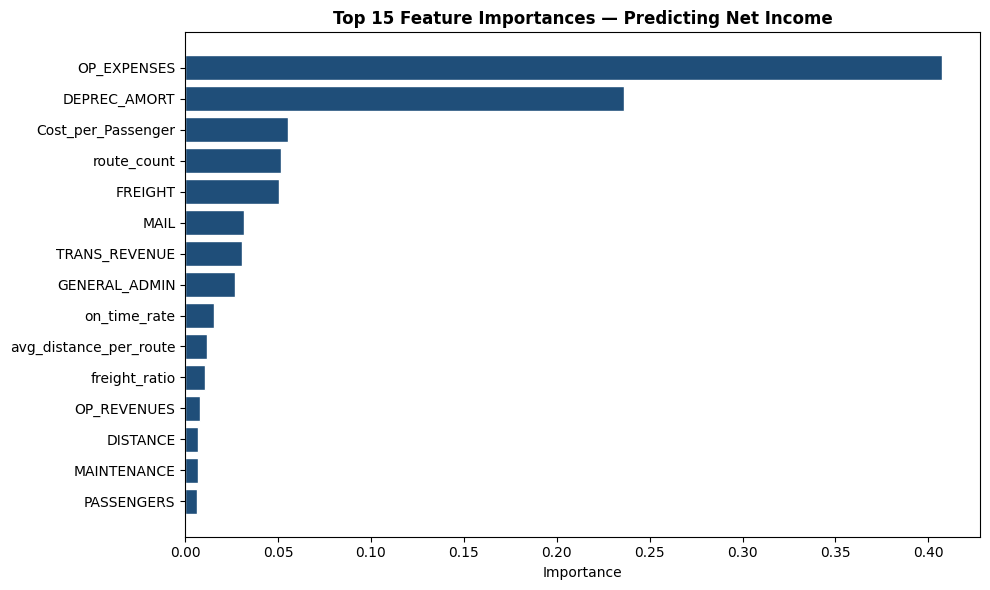

Figure 8 saved.


In [ ]:
imp_df = pd.DataFrame({
    'Feature':    features_clean,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
        color='#1f4e79', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Predicting Net Income',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance', fontsize=10)
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

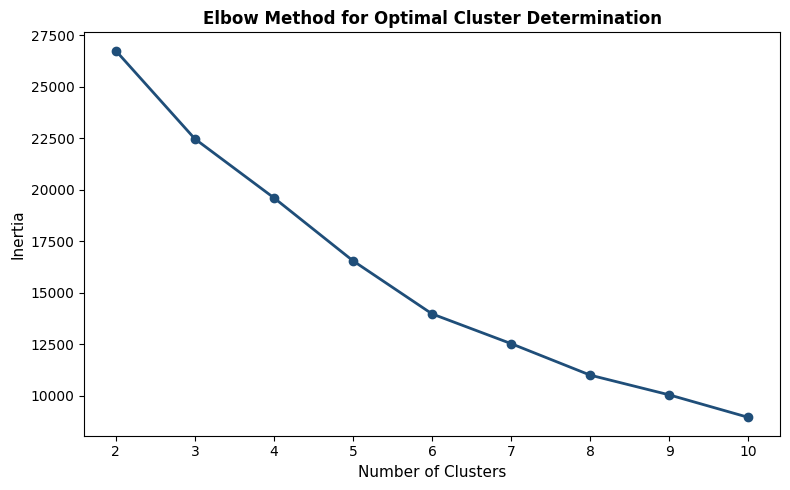

Figure 9 saved.


In [ ]:
cluster_features = [
    'PASSENGERS','FREIGHT','MAIL','DISTANCE','route_count',
    'avg_passengers_per_route','avg_distance_per_route',
    'freight_ratio','mail_ratio','network_size',
    'OP_REVENUES','OP_EXPENSES','Operating_Margin','Net_Margin',
    'Cost_per_Passenger','Revenue_per_Passenger',
    'on_time_rate','cancellation_rate'
]
cluster_features = [c for c in cluster_features if c in model_df.columns]

X_cluster = model_df[cluster_features].fillna(0)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertia, marker='o', color='#1f4e79', linewidth=2)
ax.set_xlabel('Number of Clusters', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11)
ax.set_title('Elbow Method for Optimal Cluster Determination',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
model_df = model_df.copy()
model_df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = (
    model_df.groupby('Cluster')[[
        'PASSENGERS','OP_REVENUES','OP_EXPENSES',
        'Operating_Margin','Cost_per_Passenger',
        'NET_INCOME_FINAL','on_time_rate','cancellation_rate'
    ]].mean().round(3)
)
print("Cluster profiles:")
print(cluster_profile.to_string())
print("\nCarrier type distribution by cluster:")
print(pd.crosstab(model_df['Cluster'], model_df['Carrier_Type']))

Cluster profiles:
           PASSENGERS  OP_REVENUES  OP_EXPENSES  Operating_Margin  Cost_per_Passenger  NET_INCOME_FINAL  on_time_rate  cancellation_rate
Cluster                                                                                                                                 
0        3.863053e+06   254626.658   304712.172            -0.173               0.107        -40119.986         0.820              0.026
1        2.311437e+05    54318.787    53289.673            -0.206             800.251         -1921.956           NaN                NaN
2        0.000000e+00  1259897.074  1617273.618            -0.458                 NaN       -252039.905           NaN                NaN
3        2.917488e+07  1597013.279  1813309.796            -0.084               0.086       -186837.756         0.825              0.017

Carrier type distribution by cluster:
Carrier_Type  Cargo  Legacy  Low-Cost  Other  Regional
Cluster                                               
0          

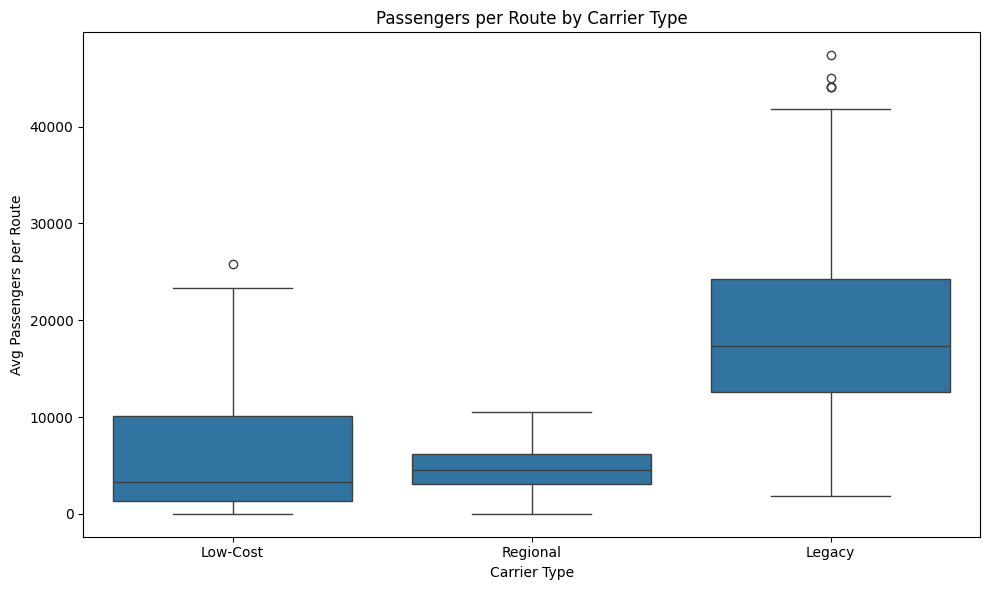

In [ ]:
import seaborn as sns

util_df = agg_df[
    agg_df['Carrier_Type'].isin(['Legacy', 'Low-Cost', 'Regional'])
].dropna(subset=['avg_passengers_per_route'])

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=util_df,
    x='Carrier_Type',
    y='avg_passengers_per_route',
    ax=ax
)

ax.set_title('Passengers per Route by Carrier Type')
ax.set_xlabel('Carrier Type')
ax.set_ylabel('Avg Passengers per Route')

plt.tight_layout()
plt.show()

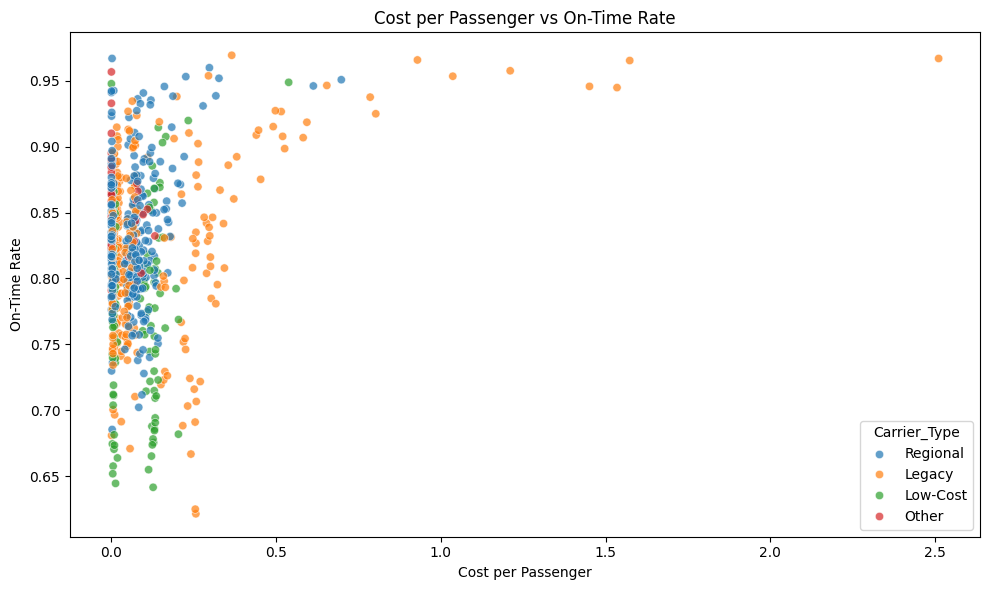

In [ ]:
scatter_df = agg_df.dropna(subset=['Cost_per_Passenger', 'on_time_rate', 'Carrier_Type']).copy()
scatter_df = scatter_df[scatter_df['Cost_per_Passenger'].between(0, 500)]

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=scatter_df,
    x='Cost_per_Passenger',
    y='on_time_rate',
    hue='Carrier_Type',
    alpha=0.7,
    ax=ax
)

ax.set_title('Cost per Passenger vs On-Time Rate')
ax.set_xlabel('Cost per Passenger')
ax.set_ylabel('On-Time Rate')

plt.tight_layout()
plt.show()

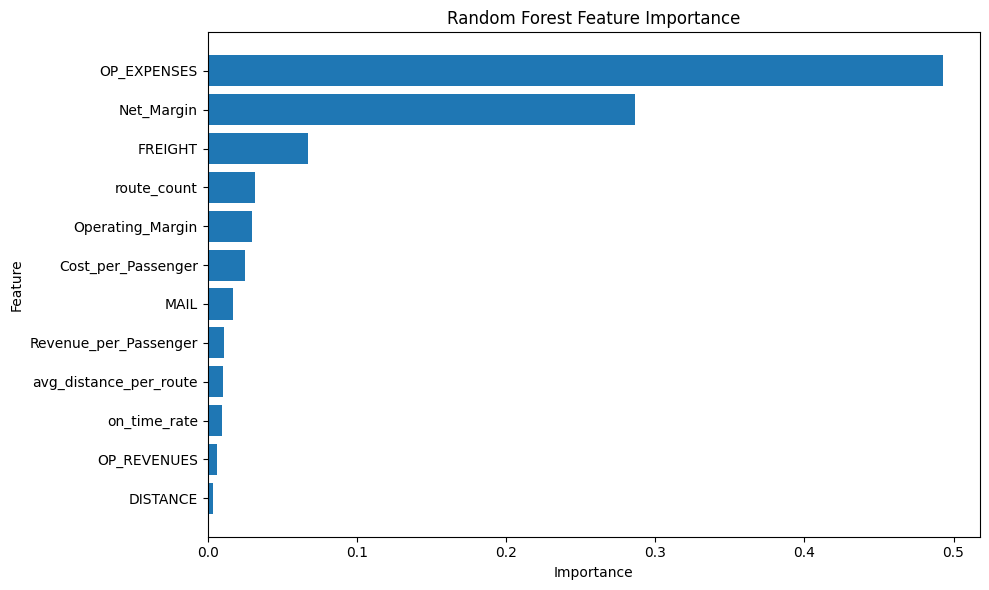

In [ ]:
rf_features = [
    'PASSENGERS', 'FREIGHT', 'MAIL', 'DISTANCE', 'route_count',
    'avg_passengers_per_route', 'avg_distance_per_route',
    'OP_REVENUES', 'OP_EXPENSES',
    'Operating_Margin', 'Net_Margin',
    'Cost_per_Passenger', 'Revenue_per_Passenger',
    'on_time_rate', 'cancellation_rate', 'avg_arr_delay_min'
]

rf_df = agg_df.dropna(subset=['NET_INCOME_FINAL']).copy()
X = rf_df[rf_features]
y = rf_df['NET_INCOME_FINAL']

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_imp, y)


imp_df = pd.DataFrame({
    'Feature': rf_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1])

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

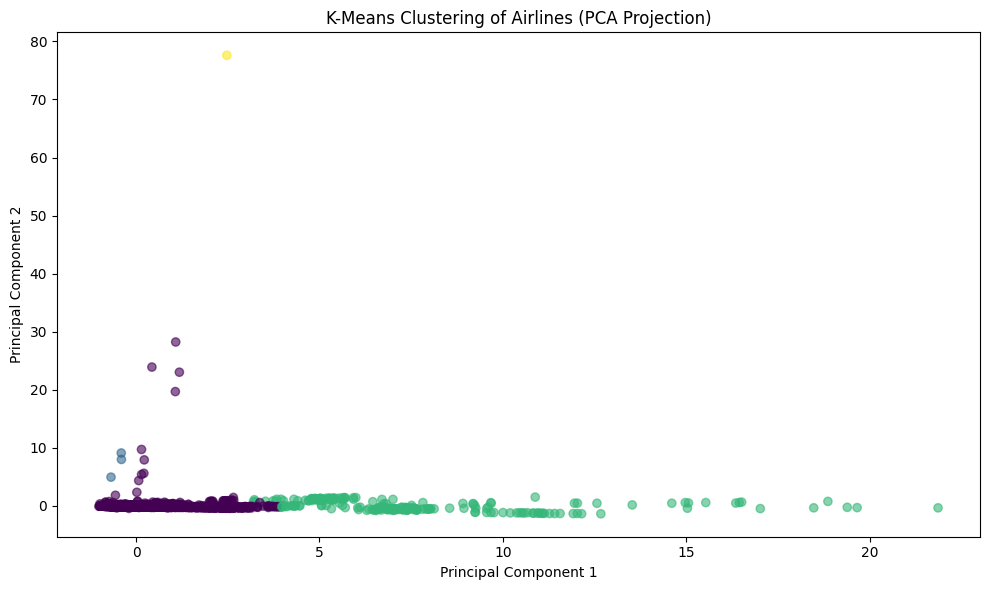

In [ ]:
cluster_features = [
    'PASSENGERS', 'FREIGHT', 'MAIL', 'DISTANCE', 'route_count',
    'avg_passengers_per_route', 'avg_distance_per_route',
    'OP_REVENUES', 'OP_EXPENSES',
    'Operating_Margin', 'Net_Margin',
    'Cost_per_Passenger', 'Revenue_per_Passenger'
]

clust_df = agg_df[cluster_features].copy()

clust_df = clust_df.fillna(clust_df.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clust_df)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, alpha=0.6)

plt.title('K-Means Clustering of Airlines (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

In [ ]:
reg_df = agg_df.copy()

reg_cols = [
    'NET_INCOME_FINAL',
    'PASSENGERS',
    'FREIGHT',
    'MAIL',
    'DISTANCE',
    'route_count',
    'avg_passengers_per_route',
    'Cost_per_Passenger',
    'on_time_rate',
    'cancellation_rate',
    'Carrier_Type',
    'period'
]

reg_df = reg_df[[c for c in reg_cols if c in reg_df.columns]].copy()
reg_df = reg_df.replace([np.inf, -np.inf], np.nan)

for col in ['PASSENGERS', 'FREIGHT', 'MAIL', 'DISTANCE', 'route_count', 'avg_passengers_per_route']:
    if col in reg_df.columns:
        reg_df[f'log_{col}'] = np.log1p(reg_df[col])

reg_df = reg_df.dropna(subset=['NET_INCOME_FINAL'])

print("Regression sample size:", reg_df.shape)
reg_df.head()

Regression sample size: (1825, 17)


,NET_INCOME_FINAL,PASSENGERS,FREIGHT,MAIL,DISTANCE,route_count,avg_passengers_per_route,Cost_per_Passenger,on_time_rate,cancellation_rate,Carrier_Type,log_PASSENGERS,log_FREIGHT,log_MAIL,log_DISTANCE,log_route_count,log_avg_passengers_per_route
42,3046.58,36654,0,0,598282,700,52.362857,0.493596,NaN,NaN,Other,10.509305,0.000000,0.000000,13.301819,6.552508,3.977115
43,762.04,17688,224,10851,205655,202,87.564356,0.823783,NaN,NaN,Other,9.780698,5.416100,9.292105,12.233960,5.313206,4.483729
44,1332.99,30019,74,0,294641,296,101.415541,0.543355,NaN,NaN,Other,10.309619,4.317488,0.000000,12.593516,5.693732,4.629038
45,1623.98,49548,0,0,587959,638,77.661442,0.417385,NaN,NaN,Other,10.810717,0.000000,0.000000,13.284414,6.459904,4.365153
46,2861.17,63482,508,11122,745816,932,68.113734,0.339272,NaN,NaN,Other,11.058527,6.232448,9.316770,13.522236,6.838405,4.235753


In [ ]:
reg_df = agg_df.copy()

reg_cols = [
    'NET_INCOME_FINAL',
    'PASSENGERS',
    'FREIGHT',
    'MAIL',
    'DISTANCE',
    'route_count',
    'avg_passengers_per_route',
    'Cost_per_Passenger',
    'on_time_rate',
    'cancellation_rate',
    'Carrier_Type',
    'Period'
]

reg_df = reg_df[[c for c in reg_cols if c in reg_df.columns]].copy()

In [ ]:
for col in ['PASSENGERS', 'FREIGHT', 'avg_passengers_per_route']:
    reg_df[f'log_{col}'] = np.log1p(reg_df[col])

In [ ]:
model_df = reg_df.dropna(subset=[
    'NET_INCOME_FINAL',
    'log_PASSENGERS',
    'log_FREIGHT',
    'log_avg_passengers_per_route',
    'on_time_rate',
    'cancellation_rate',
    'Carrier_Type',
    'Period'
]).copy()

formula = """
NET_INCOME_FINAL ~ log_PASSENGERS
                 + log_FREIGHT
                 + log_avg_passengers_per_route
                 + on_time_rate
                 + cancellation_rate
                 + C(Carrier_Type)
                 + C(Period)
"""

ols_model = smf.ols(formula=formula, data=model_df).fit(cov_type='HC3')
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:       NET_INCOME_FINAL   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     6.119
Date:                Sat, 02 May 2026   Prob (F-statistic):           5.93e-09
Time:                        20:02:39   Log-Likelihood:                -9387.4
No. Observations:                 671   AIC:                         1.880e+04
Df Residuals:                     660   BIC:                         1.885e+04
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

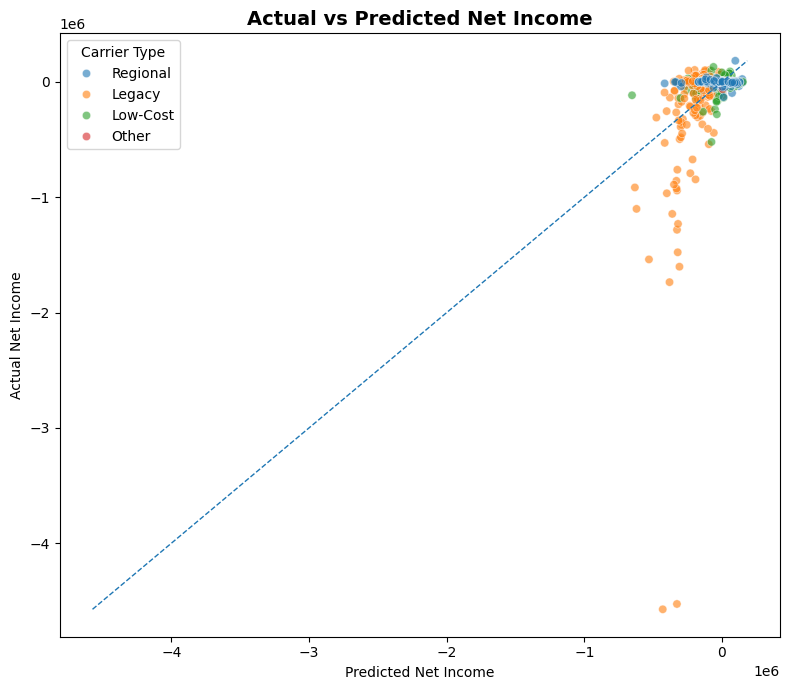

In [ ]:
model_df['predicted'] = ols_model.predict(model_df)

plt.figure(figsize=(8, 7))

sns.scatterplot(
    data=model_df,
    x='predicted',
    y='NET_INCOME_FINAL',
    hue='Carrier_Type',
    alpha=0.6
)

lims = [
    min(model_df['predicted'].min(), model_df['NET_INCOME_FINAL'].min()),
    max(model_df['predicted'].max(), model_df['NET_INCOME_FINAL'].max())
]

plt.plot(lims, lims, linestyle='--', linewidth=1)

plt.title('Actual vs Predicted Net Income', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Net Income')
plt.ylabel('Actual Net Income')
plt.legend(title='Carrier Type')

plt.tight_layout()
plt.savefig('fig_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_682/2763969677.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


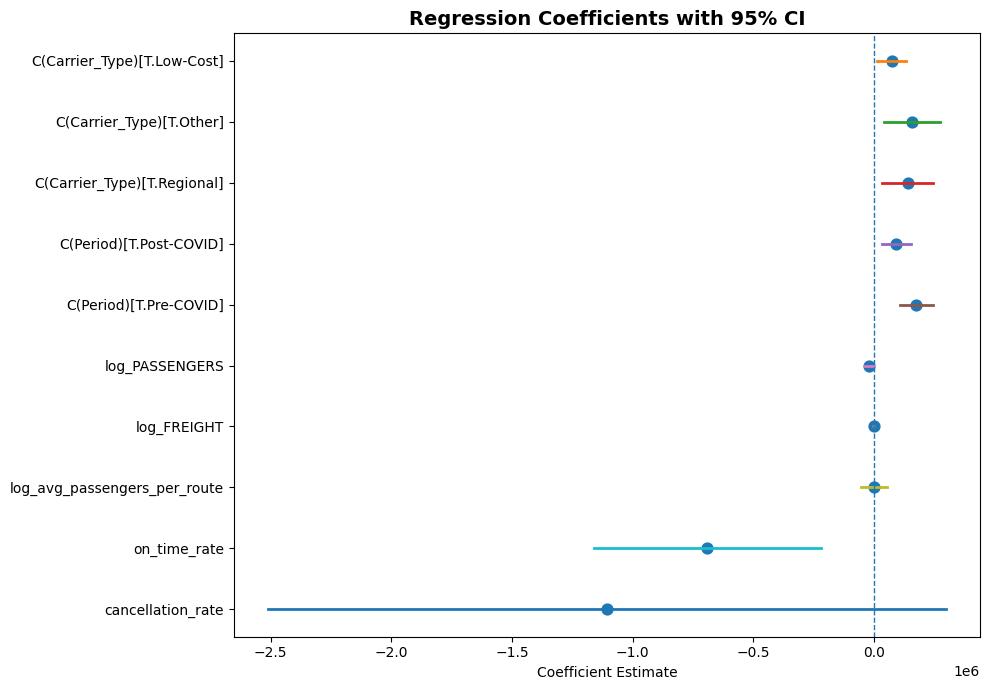

In [ ]:
coef_df = pd.DataFrame({
    'term': ols_model.params.index,
    'coef': ols_model.params.values,
    'lower': ols_model.conf_int()[0],
    'upper': ols_model.conf_int()[1],
    'pval': ols_model.pvalues
})

coef_df = coef_df[coef_df['term'] != 'Intercept']

plt.figure(figsize=(10, 7))

sns.pointplot(
    data=coef_df,
    y='term',
    x='coef',
    join=False
)

for i, row in coef_df.reset_index(drop=True).iterrows():
    plt.plot([row['lower'], row['upper']], [i, i], linewidth=2)

plt.axvline(0, linestyle='--', linewidth=1)

plt.title('Regression Coefficients with 95% CI', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Estimate')
plt.ylabel('')

plt.tight_layout()
plt.savefig('fig_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

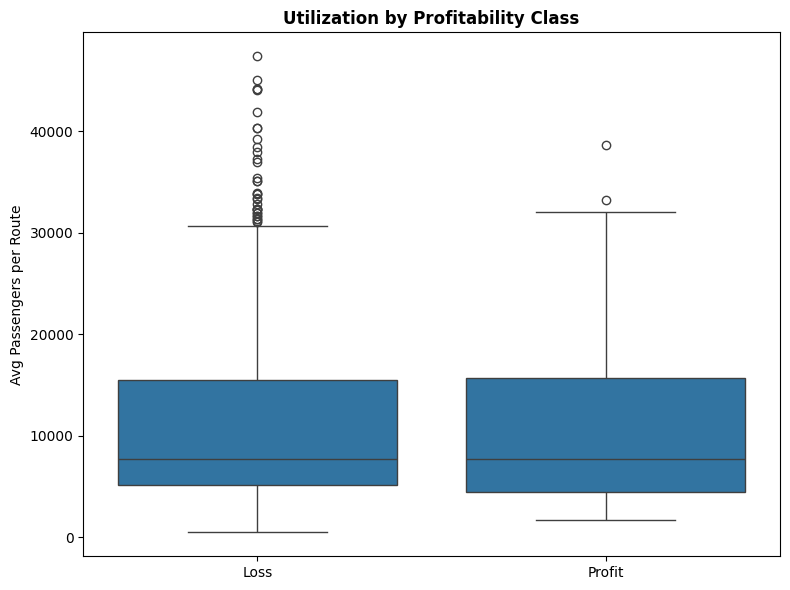

In [ ]:
model_df['profitable'] = (model_df['NET_INCOME_FINAL'] > 0).astype(int)
plt.figure(figsize=(8,6))

sns.boxplot(
    data=model_df,
    x='profitable',
    y='avg_passengers_per_route'
)

plt.xticks([0,1], ['Loss', 'Profit'])
plt.title('Utilization by Profitability Class', fontweight='bold')
plt.xlabel('')
plt.ylabel('Avg Passengers per Route')

plt.tight_layout()
plt.savefig('fig_classification_utilization.png', dpi=300)
plt.show()

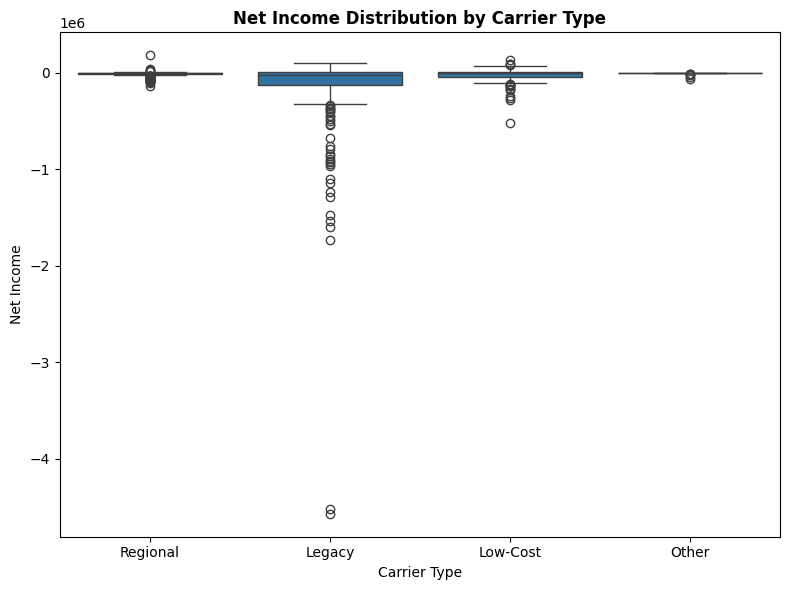

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=model_df,
    x='Carrier_Type',
    y='NET_INCOME_FINAL'
)

plt.title('Net Income Distribution by Carrier Type', fontweight='bold')
plt.xlabel('Carrier Type')
plt.ylabel('Net Income')

plt.tight_layout()
plt.savefig('fig_income_by_carrier.png', dpi=300)
plt.show()

In [ ]:
possible_carrier_cols = [
    'UNIQUE_CARRIER',
    'UNIQUE_CARRIER_FINAL',
    'UNIQUE_CARRIER_x',
    'UNIQUE_CARRIER_y',
    'OP_UNIQUE_CARRIER',
    'carrier'
]

carrier_col = next((c for c in possible_carrier_cols if c in agg_df.columns), None)

if carrier_col is None:
    print("Available carrier-like columns:")
    print([c for c in agg_df.columns if 'CARRIER' in c.upper()])
    raise KeyError("No usable carrier-code column found in agg_df.")

def classify_carrier(carrier):
    if carrier in ['AA', 'DL', 'UA']:
        return 'Legacy'
    elif carrier in ['WN', 'B6', 'NK', 'F9']:
        return 'Low-Cost'
    elif carrier in ['OO', 'YX', 'EV', 'MQ']:
        return 'Regional'
    elif carrier in ['FX', '5X']:
        return 'Cargo'
    else:
        return 'Other'

agg_df['Carrier_Type'] = agg_df[carrier_col].apply(classify_carrier)

print("Using carrier column:", carrier_col)
print(agg_df['Carrier_Type'].value_counts())

Using carrier column: UNIQUE_CARRIER_FINAL
Carrier_Type
Other       3985
Low-Cost     144
Regional     131
Legacy       108
Cargo         72
Name: count, dtype: int64


In [ ]:
model_df = agg_df.copy()

for col in ['PASSENGERS', 'FREIGHT', 'avg_passengers_per_route']:
    if col in model_df.columns:
        model_df[f'log_{col}'] = np.log1p(model_df[col])

print(model_df['Carrier_Type'].value_counts())

Carrier_Type
Other       3985
Low-Cost     144
Regional     131
Legacy       108
Cargo         72
Name: count, dtype: int64


In [ ]:
model_df = model_df[model_df['Carrier_Type'] != 'Other']

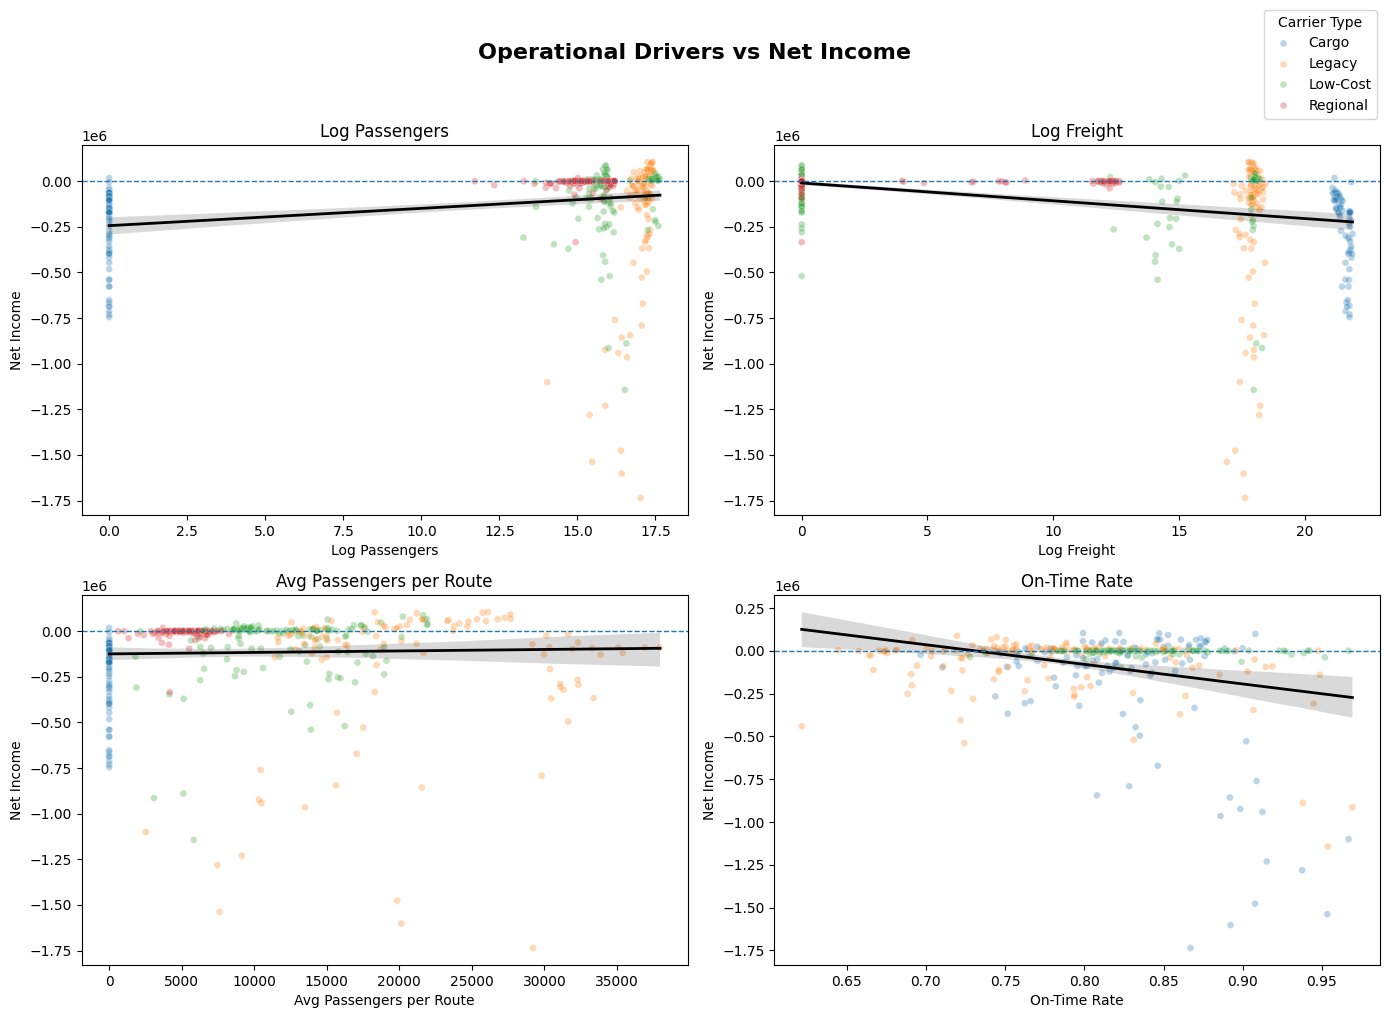

In [ ]:
plot_df_base = model_df[
    model_df['NET_INCOME_FINAL'].between(-2_000_000, 500_000)
].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plots = [
    ('log_PASSENGERS', 'Log Passengers'),
    ('log_FREIGHT', 'Log Freight'),
    ('avg_passengers_per_route', 'Avg Passengers per Route'),
    ('on_time_rate', 'On-Time Rate')
]

handles, labels = None, None

for i, (ax, (var, label)) in enumerate(zip(axes, plots)):

    df_plot = plot_df_base[[var, 'NET_INCOME_FINAL', 'Carrier_Type']].dropna()

    sns.scatterplot(
        data=df_plot,
        x=var,
        y='NET_INCOME_FINAL',
        hue='Carrier_Type',
        alpha=0.30,
        s=24,
        ax=ax
    )

    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    if ax.legend_ is not None:
        ax.legend_.remove()

    sns.regplot(
        data=df_plot,
        x=var,
        y='NET_INCOME_FINAL',
        scatter=False,
        ax=ax,
        line_kws={'color': 'black', 'linewidth': 2}
    )

    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(label)
    ax.set_ylabel('Net Income')

fig.legend(
    handles,
    labels,
    title='Carrier Type',
    loc='upper right',
    bbox_to_anchor=(0.992, 1.02),
    frameon=True,
    fontsize=10,
    title_fontsize=10
)

plt.suptitle(
    'Operational Drivers vs Net Income',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('fig_inferential_4panel.png', dpi=300, bbox_inches='tight')
plt.show()